In [66]:
from sklearn.datasets import load_digits as ld
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale
from sklearn.model_selection import train_test_split as ttSplit
from sklearn.cluster import KMeans
from sklearn import metrics
from matplotlib import pyplot
import numpy

In [67]:
DataSet = ld()
print(DataSet)

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]]), 'target': array([0, 1, 2, ..., 8, 9, 8]), 'frame': None, 'feature_names': ['pixel_0_0', 'pixel_0_1', 'pixel_0_2', 'pixel_0_3', 'pixel_0_4', 'pixel_0_5', 'pixel_0_6', 'pixel_0_7', 'pixel_1_0', 'pixel_1_1', 'pixel_1_2', 'pixel_1_3', 'pixel_1_4', 'pixel_1_5', 'pixel_1_6', 'pixel_1_7', 'pixel_2_0', 'pixel_2_1', 'pixel_2_2', 'pixel_2_3', 'pixel_2_4', 'pixel_2_5', 'pixel_2_6', 'pixel_2_7', 'pixel_3_0', 'pixel_3_1', 'pixel_3_2', 'pixel_3_3', 'pixel_3_4', 'pixel_3_5', 'pixel_3_6', 'pixel_3_7', 'pixel_4_0', 'pixel_4_1', 'pixel_4_2', 'pixel_4_3', 'pixel_4_4', 'pixel_4_5', 'pixel_4_6', 'pixel_4_7', 'pixel_5_0', 'pixel_5_1', 'pixel_5_2', 'pixel_5_3', 'pixel_5_4', 'pixel_5_5', 'pixel_5_6', 'pixel_5_7', 'pixel_6_0', '

In [68]:
DataSet.data.shape

(1797, 64)

In [69]:
pcA = PCA(2)

In [70]:
pcAData = pcA.fit_transform(DataSet.data)
pcAData.shape
#pyplot.plot(pcAData)

(1797, 2)

In [71]:
sum(pcA.explained_variance_ratio_*100)

28.509364823692117

In [72]:
ClusterDataSet = ld()
ClusterDataSet.data = scale(ClusterDataSet.data)

In [73]:
Kmean = KMeans(init='k-means++',n_clusters=10,random_state=0)

In [74]:
data_train = pcA.fit_transform(ClusterDataSet.data)

In [75]:
TrainSet_train,TrainSet_test,TestSet_train,TestSet_test = ttSplit(data_train,ClusterDataSet.target,test_size=0.2)

c:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


array([7, 0, 5, 3, 5, 5, 5, 6, 0, 2, 4, 4, 4, 9, 7, 7, 0, 5, 5, 0, 0, 0,
       6, 8, 6, 5, 6, 5, 8, 5, 1, 3, 2, 6, 0, 8, 9, 2, 1, 7, 5, 7, 7, 8,
       8, 2, 1, 1, 5, 8, 6, 1, 7, 6, 8, 8, 6, 2, 0, 8, 9, 0, 6, 6, 9, 6,
       5, 4, 5, 6, 5, 6, 4, 6, 7, 5, 1, 4, 5, 8, 8, 8, 5, 7, 6, 7, 1, 9,
       0, 5, 2, 5, 0, 5, 9, 5, 9, 9, 3, 4, 5, 8, 1, 6, 3, 0, 7, 3, 7, 7,
       2, 2, 9, 5, 1, 9, 5, 5, 9, 3, 7, 0, 7, 5, 4, 8, 8, 1, 6, 7, 1, 6,
       8, 7, 0, 2, 7, 2, 8, 3, 8, 7, 4, 5, 3, 2, 3, 3, 6, 8, 2, 0, 1, 2,
       3, 1, 0, 7, 8, 5, 4, 0, 6, 0, 6, 7, 1, 6, 6, 7, 6, 0, 1, 3, 5, 6,
       2, 5, 2, 8, 3, 2, 9, 6, 5, 6, 2, 9, 9, 0, 2, 2, 2, 5, 0, 8, 5, 7,
       0, 6, 5, 0, 9, 9, 1, 8, 2, 2, 7, 1, 9, 9, 1, 5, 3, 0, 5, 5, 8, 5,
       6, 0, 8, 4, 9, 8, 1, 5, 8, 5, 0, 5, 9, 4, 1, 6, 8, 1, 9, 7, 8, 4,
       5, 5, 9, 9, 6, 6, 1, 5, 0, 7, 5, 3, 1, 8, 7, 6, 6, 1, 3, 7, 1, 2,
       3, 2, 3, 1, 5, 5, 5, 3, 8, 5, 9, 1, 7, 6, 8, 8, 0, 1, 1, 9, 9, 8,
       6, 7, 6, 6, 1, 6, 8, 0, 1, 2, 6, 7, 8, 6, 2,

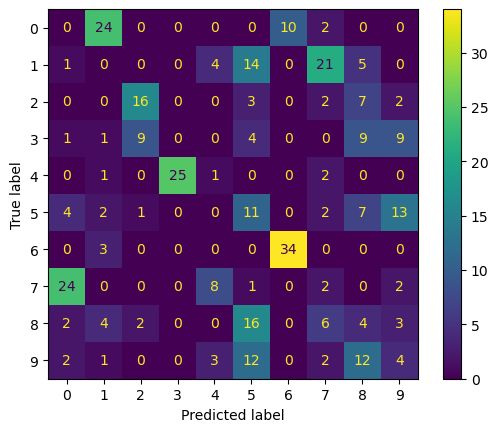

In [76]:
Kmean.fit(TrainSet_train)
Label_K = Kmean.predict(TrainSet_test) 
cm = metrics.confusion_matrix(TestSet_test, Label_K)
metrics.ConfusionMatrixDisplay(confusion_matrix=cm).plot()
Label_K

In [77]:
Cluster_center = Kmean.cluster_centers_ 

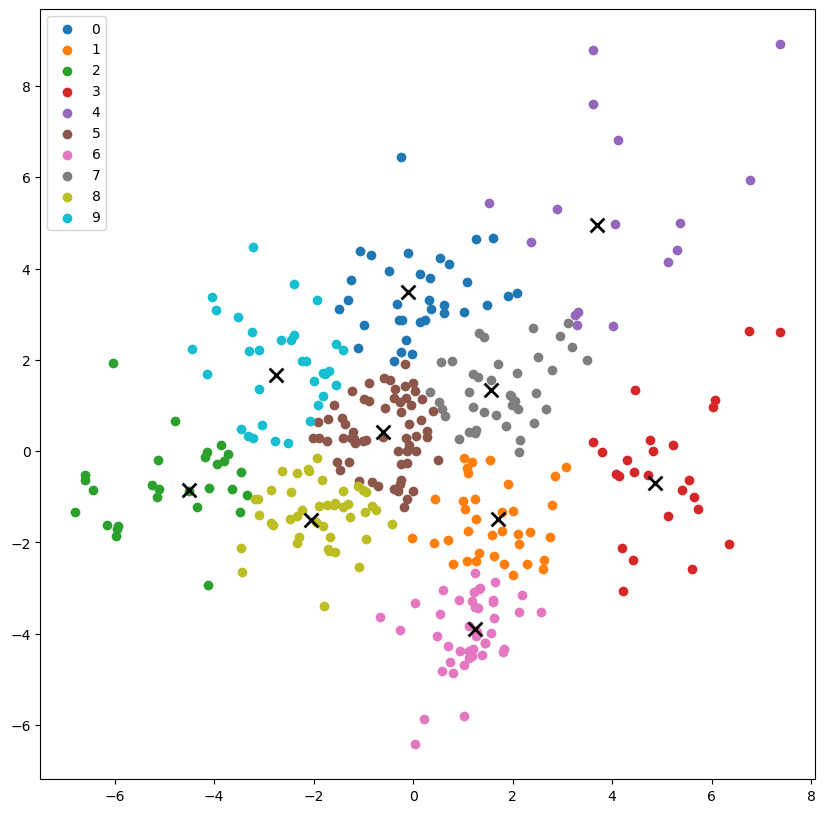

In [78]:
pyplot.figure(figsize=(10, 10)) 
for i in numpy.unique(Label_K): 
    pyplot.scatter(TrainSet_test[Label_K == i, 0], TrainSet_test[Label_K == i, 1], label=i) 
pyplot.scatter(Cluster_center[:, 0], Cluster_center[:, 1], marker='x', s=100, linewidths=2, color='k', zorder=10) 
pyplot.legend() 
pyplot.show()